# Development turnover

How much development are we actually getting? There's an ill-defined notion of 'overdevelopment' that is raised as a reason to hinder development. I obviously don't buy that,
but it would be helpful to in some way quantify the development that is happening.

For those would like to see development in our city to improve our quality of life, reduce inflation, and increase opportunities, we'd like to see the development metrics trending upwards.

In [1]:
import folium
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

from investigations.development_turnover import fetch
from investigations import plot_parcel_at_scale
from waltham import quirks

In [2]:
# ── Redeveloped parcels per year ──────────────────────────────────────────
# "redeveloped"   – existing building replaced with a newer one
# "new_on_vacant" – parcel had no prior building; one was newly constructed
# Both signals use YEAR_BUILT within 3 years of the assessment snapshot to
# distinguish genuine new construction from assessor data corrections.
redevelopment_df = fetch.fetch_redevelopment_counts()

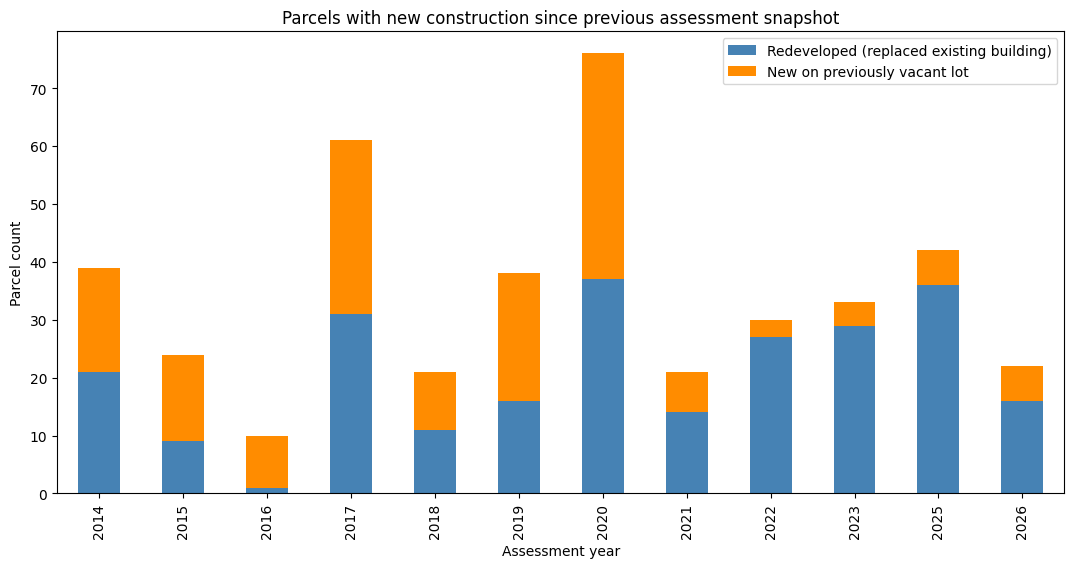

In [3]:
ax = redevelopment_df.plot.bar(
    x="year",
    y=["redeveloped", "new_on_vacant"],
    stacked=True,
    title="Parcels with new construction since previous assessment snapshot",
    figsize=(13, 6),
    color=["steelblue", "darkorange"],
)
ax.set_xlabel("Assessment year")
ax.set_ylabel("Parcel count")
ax.legend(["Redeveloped (replaced existing building)", "New on previously vacant lot"])
plt.show()

In [4]:
# ── Housing units year-over-year ──────────────────────────────────────────
# Residential parcels: USE_CODE < 200
units_df = fetch.fetch_units_by_year()

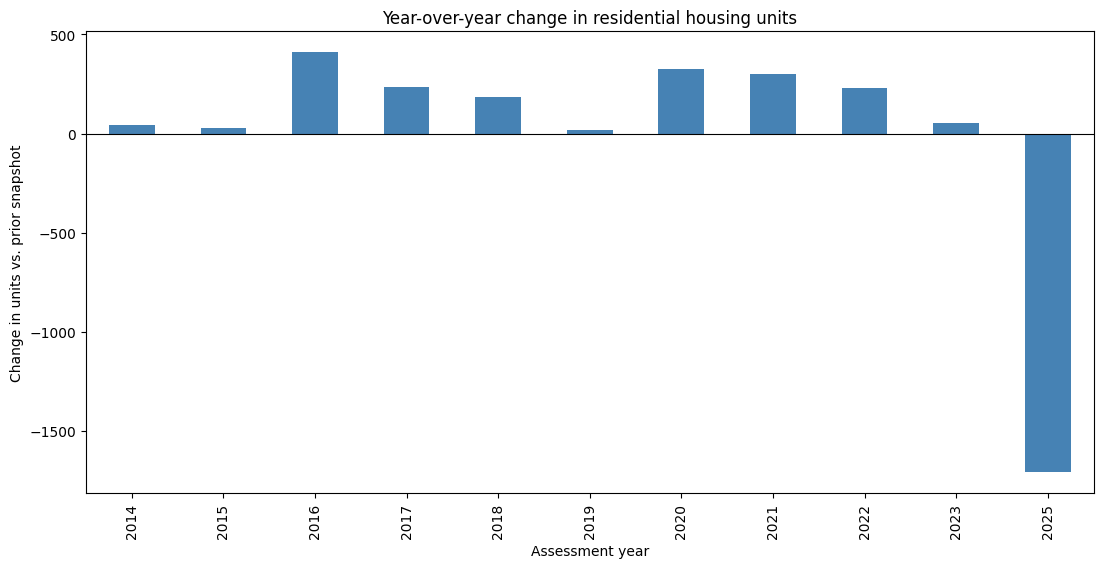

In [5]:
ax2 = units_df.dropna(subset=["units_change"]).plot.bar(
    x="year",
    y="units_change",
    title="Year-over-year change in residential housing units",
    figsize=(13, 6),
    legend=False,
    color="steelblue",
)
ax2.set_xlabel("Assessment year")
ax2.set_ylabel("Change in units vs. prior snapshot")
ax2.axhline(0, color="black", linewidth=0.8)
plt.show()

In [6]:
units_df

,year,total_units,units_change
0,2011,24276,NaN
1,2014,24320,44.0
2,2015,24348,28.0
3,2016,24757,409.0
4,2017,24990,233.0
5,2018,25175,185.0
6,2019,25194,19.0
7,2020,25518,324.0
8,2021,25818,300.0
9,2022,26046,228.0


In [7]:
all_parcels = fetch.fetch_parcel_geometry()
turnover_geo = fetch.fetch_turnover_geodata()

In [8]:
# Change this value to explore different assessment years
year_options = sorted(turnover_geo["year"].unique().tolist())
selected_year = year_options[-1]
print(f"Available years: {year_options}")
print(f"Selected year: {selected_year}")

Available years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2025, 2026]
Selected year: 2026


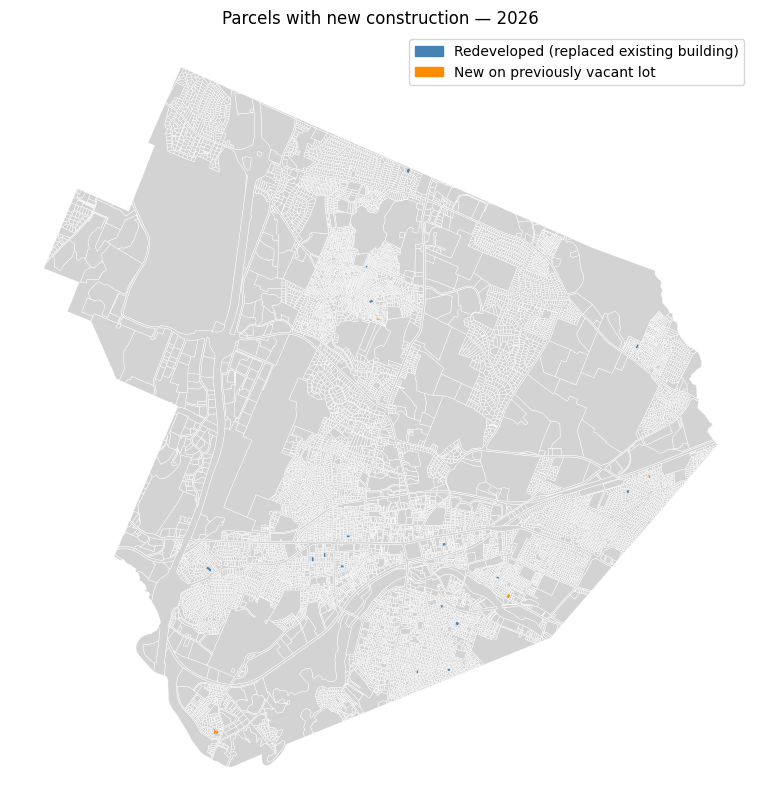

In [9]:
_subset = turnover_geo[turnover_geo["year"] == selected_year]
_colors = {"redeveloped": "steelblue", "new_on_vacant": "darkorange"}

_fig, _ax = plt.subplots(figsize=(13, 10))
all_parcels.plot(ax=_ax, color="lightgray", edgecolor="white", linewidth=0.3)
for _t, _grp in _subset.groupby("turnover_type"):
    _grp.plot(ax=_ax, color=_colors[_t], label=_t)

_ax.set_title(f"Parcels with new construction — {selected_year}")
_ax.set_axis_off()
_ax.legend(
    handles=[
        mpatches.Patch(color="steelblue", label="Redeveloped (replaced existing building)"),
        mpatches.Patch(color="darkorange", label="New on previously vacant lot"),
    ]
)
plt.show()

In [ ]:
turnover_detail = fetch.fetch_turnover_with_details()

_all_wgs84 = all_parcels.to_crs(epsg=4326)
_turnover_wgs84 = turnover_detail.to_crs(epsg=4326)

_center = _all_wgs84.geometry.unary_union.centroid
_bounds = _all_wgs84.total_bounds
_m = folium.Map(
    location=[_center.y, _center.x],
    zoom_start=14,
    tiles=None,
    max_bounds=True,
    min_zoom=12,
    min_lat=_bounds[1] - 0.01,
    max_lat=_bounds[3] + 0.01,
    min_lon=_bounds[0] - 0.01,
    max_lon=_bounds[2] + 0.01,
)
folium.TileLayer("CartoDB positron", control=False).add_to(_m)

# Background: all parcels in light gray, no tooltip
folium.GeoJson(
    _all_wgs84,
    style_function=lambda _: {
        "fillColor": "lightgray",
        "color": "white",
        "weight": 0.3,
        "fillOpacity": 0.5,
    },
    name="All parcels",
    show=True,
).add_to(_m)

# One layer per year; parcels colored by turnover_type within each layer
_type_color = {"redeveloped": "steelblue", "new_on_vacant": "darkorange"}
for _yr, _grp in _turnover_wgs84.groupby("year"):
    folium.GeoJson(
        _grp,
        style_function=lambda f: {
            "fillColor": _type_color.get(f["properties"]["turnover_type"], "gray"),
            "color": _type_color.get(f["properties"]["turnover_type"], "gray"),
            "weight": 1,
            "fillOpacity": 0.8,
        },
        tooltip=folium.GeoJsonTooltip(
            fields=[
                "LOC_ID",
                "turnover_type",
                "year_prev",
                "year_built_prev",
                "units_prev",
                "use_code_prev",
                "year",
                "year_built_new",
                "units_new",
                "use_code_new",
            ],
            aliases=[
                "Parcel",
                "Change type",
                "Previous snapshot",
                "\u2022 Year built",
                "\u2022 Units",
                "\u2022 Use code",
                "New snapshot",
                "\u2022 Year built",
                "\u2022 Units",
                "\u2022 Use code",
            ],
        ),
        name=str(_yr),
        show=False,
    ).add_to(_m)

folium.LayerControl(collapsed=False).add_to(_m)

_m.save("published/development_turnover.html")
_m

## Potential condo conversions

LOC_IDs with multifamily residential use codes (102–129, 141–199) where
`COUNT(DISTINCT PROP_ID)` increases between consecutive snapshots.  A growing
PROP_ID count on the same parcel is the expected footprint of a condo
conversion: what was a single assessment record becomes one record per unit.
The `units_change` column shows whether the assessor's unit tally tracked the
conversion or silently dropped units.

In [11]:
splits_df = fetch.fetch_prop_id_splits()
splits_df

,year_prev,year,LOC_ID,prop_count_old,prop_count_new,units_old,units_new,units_change,use_codes_old,use_codes_new
0,2011,2014,F_726982_2958262,1,3,11,3,-8,121,102
1,2011,2014,F_720457_2956778,1,4,8,4,-4,111,102
2,2011,2014,F_727359_2958629,1,2,4,2,-2,104,102
3,2011,2014,F_726583_2958455,1,6,8,6,-2,111,102
4,2011,2014,F_727757_2957871,1,3,5,3,-2,111,102
...,...,...,...,...,...,...,...,...,...,...
291,2025,2026,F_725492_2964588,1,2,2,0,-2,104,102
292,2025,2026,F_726457_2960040,1,2,2,0,-2,109,"109,131"
293,2025,2026,F_723867_2961046,2,3,2,0,-2,102,"102,343"
294,2025,2026,F_728627_2959906,1,2,2,0,-2,104,102


<Axes: title={'center': 'F_723940_2972687  (1" = 100\')'}>

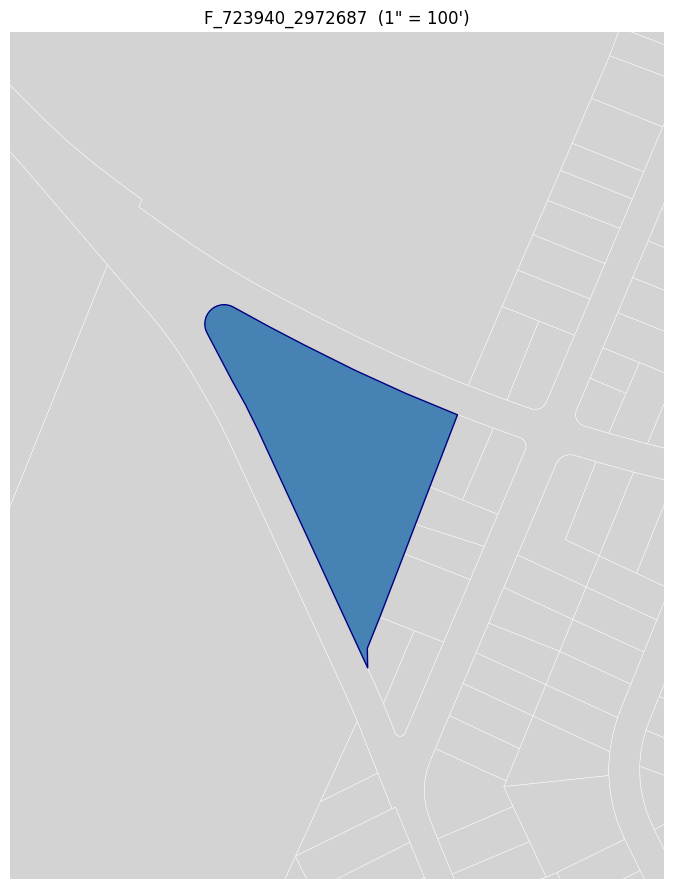

In [12]:
plot_parcel_at_scale("F_723940_2972687", all_parcels, scale=100)